In [ ]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

### `Question-1:`

The dataset is based on NFTs. This is quite large. So, when you will read the dataset, you have to wait. The link of the dataset: https://tinyurl.com/2pfhncqw

Your task is to make a pivote table by using the columns "verification_status", "contract_type", "rarity_score" and "last_sale_price" to find out the total values.

In [ ]:
# code here

### `Question-2:`

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are
- make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
- At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.

There are some challenges to solve this task:
- There is no column that is represented to the brand name of the car. You have to find out on your own.
- Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

In [ ]:
cars_price = pd.read_csv('/content/carvana - carvana (1).csv')

In [ ]:
cars_price.head()

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


In [ ]:
cars_price['Year'] = cars_price['Year'].astype(str).str[:4].astype(int)
filtered_cars_price = cars_price[cars_price['Year'].between(2018, 2022)]

In [ ]:
filtered_cars_price['Brand'] = filtered_cars_price['Name'].str.split(' ').str[0]
filtered_cars_price

/tmp/ipykernel_2328/1764131092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_cars_price['Brand'] = filtered_cars_price['Name'].str.split(' ').str[0]


,Name,Year,Miles,Price,Brand
0,Chevrolet Trax,2018,41946,16990,Chevrolet
1,GMC Terrain,2020,45328,23990,GMC
3,Jeep Renegade,2019,35372,21590,Jeep
5,Buick Encore,2019,47973,18590,Buick
24,Mitsubishi Eclipse Cross,2018,85475,16990,Mitsubishi
...,...,...,...,...,...
21976,Jeep Renegade,2020,63054,20590,Jeep
21978,Nissan Versa,2022,9975,22990,Nissan
21982,Nissan Murano,2019,38638,24990,Nissan
21987,Volkswagen Tiguan,2019,42636,24990,Volkswagen


<Axes: title={'center': 'Price and Miles Distribution (2018-2022)'}, ylabel='Density'>

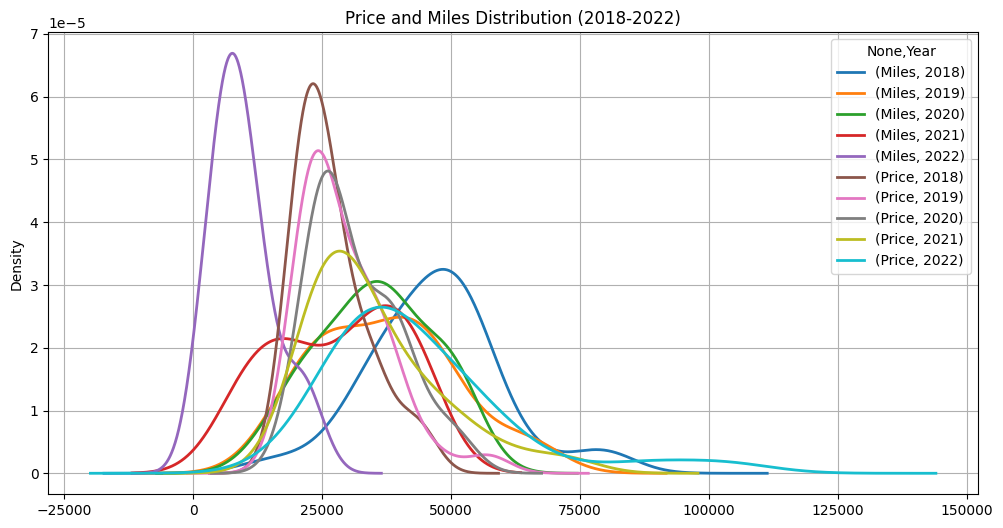

In [ ]:
filtered_cars_price.pivot_table(values=['Price','Miles'], index='Brand', columns='Year', aggfunc={'Price':'mean', 'Miles':'median'}).plot(
    kind='kde',
    figsize=(12,6),
    linewidth=2,
    title='Price and Miles Distribution (2018-2022)',
    grid=True
)

### `Question-3:`

You are given a dataset of **Daily Power Generation in India** of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task
- In this dataset, there are many columns. Two of them are `Actual(MU)` and `Excess(+) / Shortfall (-)`. `Actual(MU)` represents the actual power generation. `Excess(+) / Shortfall (-)` tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
- Find out the month of the day and store it as a new column.
- Find out top 10 frequently appeared power stations in this dataframe.
- Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
- It is hard to get inside if you look through the only pivot table. So plot the pivot table.

In [ ]:
power_generation = pd.read_csv('/content/PowerGeneration - PowerGeneration.csv')
power_generation['Required(MU)'] = power_generation['Actual(MU)'] - power_generation['Excess(+) / Shortfall (-)']

In [ ]:
power_generation.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,Required(MU)
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0,13.00
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0,28.80
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0,40.37
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0,13.57
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0,38.69


In [ ]:
power_generation['Dates'] = pd.to_datetime(power_generation['Dates'])
power_generation['Month_of_Day'] = power_generation['Dates'].dt.day
power_generation.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,Required(MU),Month_of_Day
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0,13.00,1
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0,28.80,1
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0,40.37,1
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0,13.57,1
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0,38.69,1


In [ ]:
#2
power_generation['Power Station'].value_counts(ascending=False).head(10)

,count
Power Station,
NTPC Ltd.,9570
NHPC,5742
NPCIL,5742
GMR ENERG,5742
APL,3828
JPPVL,3828
IBPIL,3828
TATA PCL,3828
JSWEL,3828


In [ ]:
# Next create a pivot table of which every row represents a power station and every column represents a month in a order.
# Like January, February, March...
power_generation['month_name'] = power_generation['Dates'].dt.month_name()

In [ ]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
pivot_tab = power_generation.pivot_table(
    values='Actual(MU)',
    index='Power Station',
    columns='month_name',
    aggfunc='mean'
)
pivot_tab = pivot_tab.reindex()
pivot_tab

month_name,April,August,December,February,January,July,June,March,May,November,October,September
Power Station,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.925000,NaN
ABAN POWR,0.600000,0.780645,0.858757,0.843972,0.870968,1.058442,0.886667,1.130841,0.798387,0.821229,0.945455,0.783333
ACB,4.225000,3.812903,4.265537,4.397163,3.754839,4.175325,4.600000,4.654206,4.290323,4.480447,4.006061,3.450000
ACPL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ADHPL,0.608333,3.761290,0.000000,0.000000,0.000000,4.194805,2.633333,0.051402,1.298387,0.011173,0.945455,2.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
VESPL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
VIP,1.466667,1.006452,3.451977,1.191489,2.561290,1.389610,1.353333,1.485981,1.491935,3.083799,3.163636,3.261111
VVL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='Power Station'>

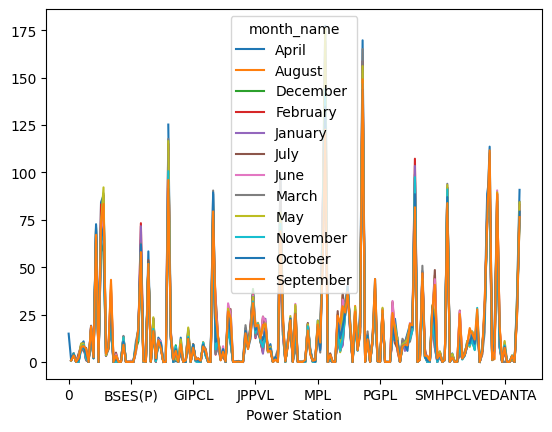

In [ ]:
pivot_tab.plot(kind='line')

###`Q-4` You are given a file `question-answer.csv`. Your task is to make a dataframe from it with two columns - `question` and `answers`.

* Questions in the file start from `Q<number>`; E.g.  `Q1` denotes question no. `1`
* Answers starts from `Ans<number>`; Eg. `Ans1` denotes answer of question no `1`
* MAke sure you look at columns name carefully

CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [ ]:
ques_ans = pd.read_csv('/content/question-answer.csv')
ques_ans.head()

,Unnamed: 0,2
0,0,Q1-What is Data Science?
1,1,"Ans1-Data Science combines statistics, maths, ..."
2,2,Q2-2. How is logistic regression done?
3,3,Ans2-Logistic regression measures the relation...
4,4,Q3-How do you build a random forest model?


In [ ]:
ques_ans = ques_ans.rename(columns={'Unnamed: 0':'sr.no.', '2':'ques_ans'})
ques_ans = ques_ans.set_index('sr.no.')

In [ ]:
question_df = ques_ans['ques_ans'].iloc[::2]
answer_df = ques_ans['ques_ans'].iloc[1::2]
question_df = question_df.reset_index(drop=True)
answer_df = answer_df.reset_index(drop=True)

In [ ]:
result_df = pd.concat([question_df, answer_df], axis=1)

In [ ]:
result_df

,ques_ans,ques_ans
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


In [ ]:
result_df.columns = ['Questions', 'Asnwers']

In [ ]:
result_df

,Questions,Asnwers
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


###`Q-5`: Print Question and answer of those questions which does not contains any question mark (`?`).


In [ ]:
# The '~' symbol means "NOT"
no_question_mark_df = result_df[~result_df['Questions'].str.contains(r'\?', na=False)]

# Display the filtered dataframe
no_question_mark_df

,Questions,Asnwers


In [ ]:
result_df['Questions'].str.contains('\?',regex=False)

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_2328/3962841348.py:1: SyntaxWarning: invalid escape sequence '\?'
  result_df['Questions'].str.contains('\?',regex=False)


,Questions
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


###`Q 6-10` LOG and EMPLOYEE
6. Show `activity` details month wise. Show count for each `activity`
7. Find employee who did most `activity` in January month.
8. Employee who have worked most no of times on Weekends.
9. Which activity is logged most on buisness days.
10. Week Days wise activity table.
```
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

```

Note(for common field):- Employee file has `EMPLOYEE_ID` and LOG file has `emp_id`

In [ ]:
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

In [ ]:
log_file.head()

,Log_ID,dt,dept,emp_id,activity,eqpt
0,1000,2022-01-07,Dept6,115,Cleaning,UPS
1,1001,2022-01-08,Dept4,105,Cleaning,Generator
2,1002,2022-01-09,Dept3,112,Inspection,CPU
3,1003,2022-01-10,Dept4,120,Inspection,UPS
4,1004,2022-01-11,Dept3,138,Checking,Battery


In [ ]:
employee.head(6)

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST
5,105,David,Austin,DAUSTIN


In [ ]:
# Q1.
log_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Log_ID    365 non-null    int64 
 1   dt        365 non-null    object
 2   dept      365 non-null    object
 3   emp_id    365 non-null    int64 
 4   activity  365 non-null    object
 5   eqpt      365 non-null    object
dtypes: int64(2), object(4)
memory usage: 17.2+ KB


In [ ]:
log_file['dt'] = pd.to_datetime(log_file['dt'])
log_file['month_name'] = log_file['dt'].dt.month_name()

In [ ]:
log_file

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January
4,1004,2022-01-11,Dept3,138,Checking,Battery,January
...,...,...,...,...,...,...,...
360,1360,2023-01-02,Dept2,122,Repair,AC,January
361,1361,2023-01-03,Dept4,116,Checking,Server,January
362,1362,2023-01-04,Dept4,110,Checking,CPU,January
363,1363,2023-01-05,Dept4,102,Inspection,AC,January


In [ ]:
log_file.groupby(['month_name','activity']).size()

month_name  activity  
April       Checking       5
            Cleaning      11
            Inspection     9
            Repair         5
August      Checking       8
            Cleaning      10
            Inspection     9
            Repair         4
December    Checking       6
            Cleaning       7
            Inspection    12
            Repair         6
February    Checking       7
            Cleaning       7
            Inspection     4
            Repair        10
January     Checking       7
            Cleaning      10
            Inspection     9
            Repair         5
July        Checking       6
            Cleaning       6
            Inspection    14
            Repair         5
June        Checking       5
            Cleaning       7
            Inspection     8
            Repair        10
March       Checking       8
            Cleaning       6
            Inspection     5
            Repair        12
May         Checking       5
            Cleaning       8
            Inspection     7
            Repair        11
November    Checking       8
            Cleaning       9
            Inspection     6
            Repair         7
October     Checking      13
            Cleaning       4
            Inspection     5
            Repair         9
September   Checking       8
            Cleaning       3
            Inspection    12
            Repair         7
dtype: int64

In [ ]:
log_file.pivot_table(index='month_name', columns='activity', values='Log_ID', aggfunc='count')

activity,Checking,Cleaning,Inspection,Repair
month_name,,,,
April,5,11,9,5
August,8,10,9,4
December,6,7,12,6
February,7,7,4,10
January,7,10,9,5
July,6,6,14,5
June,5,7,8,10
March,8,6,5,12
May,5,8,7,11


In [ ]:
merge_df = pd.merge(log_file,employee.rename(columns={'EMPLOYEE_ID':'emp_id'}), on='emp_id')
merge_df[merge_df['month_name'] == "January"].groupby(['emp_id','FIRST_NAME'])['activity'].size().sort_values(ascending=False).head(1)

,,activity
emp_id,FIRST_NAME,
122,Payam,3


In [ ]:
merge_df

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,NaN,Urman,JMURMAN
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January,Matthew,Weiss,MWEISS
4,1004,2022-01-11,Dept3,138,Checking,Battery,January,Stephen,Stiles,SSTILES
...,...,...,...,...,...,...,...,...,...,...
290,1360,2023-01-02,Dept2,122,Repair,AC,January,Payam,Kaufling,PKAUFLING
291,1361,2023-01-03,Dept4,116,Checking,Server,January,Shelli,Baida,SBAIDA
292,1362,2023-01-04,Dept4,110,Checking,CPU,January,John,Chen,JCHEN
293,1363,2023-01-05,Dept4,102,Inspection,AC,January,Lex,De Haan,LDEHAAN


In [ ]:
temp = merge_df.copy()
temp.head()

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,NaN,Urman,JMURMAN
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January,Matthew,Weiss,MWEISS
4,1004,2022-01-11,Dept3,138,Checking,Battery,January,Stephen,Stiles,SSTILES


In [ ]:
merge_df[merge_df['dt'].dt.day_name() == 'Sunday'].groupby(['emp_id','FIRST_NAME']).size().sort_values(ascending=False).head(1)

,,0
emp_id,FIRST_NAME,
109,Daniel,4


In [ ]:
merge_df['day'] = merge_df['dt'].dt.day_name()

In [ ]:
business_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
merge_df[merge_df['day'].isin(business_days)].groupby('activity').size().sort_values(ascending=False)

,0
activity,
Inspection,62
Cleaning,55
Repair,51
Checking,49


In [ ]:
merge_df.pivot_table(index='day', columns='activity',values='emp_id', aggfunc='count')

activity,Checking,Cleaning,Inspection,Repair
day,,,,
Friday,7,15,15,8
Monday,9,9,11,12
Saturday,9,8,6,11
Sunday,11,9,13,11
Thursday,8,14,14,11
Tuesday,12,8,13,11
Wednesday,13,9,9,9


### `Q-11`:

1. There are missing value in first name of employee. Fill it using email and last name field.

> E.g- `email` -> JMURMAN and `last_name` -> 'Urman' -> so make it's first name as 'JM', Sort of (Email- lastname).

> Email is constructed from initials of first name concate with lastname. Your Task is to fill first name initials in missing data.

2. You can see email field don't have any domain name. Change this to full email addreess with domain as 'campusx.com'.
E.g- Email field -> `JMURMAN`  result -> `JMURMAN@CAMPUSX.COM`

3. Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]

In [ ]:
merge_df.head(3)

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO,Friday
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN,Saturday
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,NaN,Urman,JMURMAN,Sunday


In [ ]:
merge_df.head(3)

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO,Friday
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN,Saturday
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,NaN,Urman,JMURMAN,Sunday


In [ ]:
condition = merge_df['FIRST_NAME'].isna()
merge_df.loc[condition,'FIRST_NAME'] = merge_df['EMAIL'].str[0] + merge_df['LAST_NAME'].str[0]

In [ ]:
merge_df

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO,Friday
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN,Saturday
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,JU,Urman,JMURMAN,Sunday
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January,Matthew,Weiss,MWEISS,Monday
4,1004,2022-01-11,Dept3,138,Checking,Battery,January,Stephen,Stiles,SSTILES,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
290,1360,2023-01-02,Dept2,122,Repair,AC,January,Payam,Kaufling,PKAUFLING,Monday
291,1361,2023-01-03,Dept4,116,Checking,Server,January,Shelli,Baida,SBAIDA,Tuesday
292,1362,2023-01-04,Dept4,110,Checking,CPU,January,John,Chen,JCHEN,Wednesday
293,1363,2023-01-05,Dept4,102,Inspection,AC,January,Lex,De Haan,LDEHAAN,Thursday


In [ ]:
merge_df['EMAIL'] = merge_df['EMAIL'].str[:] + '@CAMPUSX.COM'

In [ ]:
merge_df['EMAIL']

,EMAIL
0,AKHOO@CAMPUSX.COM
1,DAUSTIN@CAMPUSX.COM
2,JMURMAN@CAMPUSX.COM
3,MWEISS@CAMPUSX.COM
4,SSTILES@CAMPUSX.COM
...,...
290,PKAUFLING@CAMPUSX.COM
291,SBAIDA@CAMPUSX.COM
292,JCHEN@CAMPUSX.COM
293,LDEHAAN@CAMPUSX.COM


In [ ]:
merge_df['FULL_NAME'] = merge_df['FIRST_NAME'] + ' ' + merge_df['LAST_NAME']

In [ ]:
merge_df

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day,FULL_NAME
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday,Alexander Khoo
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN@CAMPUSX.COM,Saturday,David Austin
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,JU,Urman,JMURMAN@CAMPUSX.COM,Sunday,JU Urman
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January,Matthew,Weiss,MWEISS@CAMPUSX.COM,Monday,Matthew Weiss
4,1004,2022-01-11,Dept3,138,Checking,Battery,January,Stephen,Stiles,SSTILES@CAMPUSX.COM,Tuesday,Stephen Stiles
...,...,...,...,...,...,...,...,...,...,...,...,...
290,1360,2023-01-02,Dept2,122,Repair,AC,January,Payam,Kaufling,PKAUFLING@CAMPUSX.COM,Monday,Payam Kaufling
291,1361,2023-01-03,Dept4,116,Checking,Server,January,Shelli,Baida,SBAIDA@CAMPUSX.COM,Tuesday,Shelli Baida
292,1362,2023-01-04,Dept4,110,Checking,CPU,January,John,Chen,JCHEN@CAMPUSX.COM,Wednesday,John Chen
293,1363,2023-01-05,Dept4,102,Inspection,AC,January,Lex,De Haan,LDEHAAN@CAMPUSX.COM,Thursday,Lex De Haan


In [ ]:
names_withA = merge_df[merge_df['FULL_NAME'].str.startswith('A')]
names_withA[names_withA['activity'].isin(['Inspection', 'Cleaning', 'Checking'])]

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day,FULL_NAME
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday,Alexander Khoo
32,1038,2022-02-14,Dept2,115,Cleaning,Fan,February,Alexander,Khoo,AKHOO@CAMPUSX.COM,Monday,Alexander Khoo
78,1093,2022-04-10,Dept2,103,Checking,AC,April,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Sunday,Alexander Hunold
181,1224,2022-08-19,Dept1,103,Cleaning,AC,August,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Friday,Alexander Hunold
240,1293,2022-10-27,Dept4,115,Checking,CPU,October,Alexander,Khoo,AKHOO@CAMPUSX.COM,Thursday,Alexander Khoo
241,1294,2022-10-28,Dept6,103,Checking,Battery,October,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Friday,Alexander Hunold
251,1307,2022-11-10,Dept2,121,Inspection,AC,November,AF,Fripp,AFRIPP@CAMPUSX.COM,Thursday,AF Fripp
263,1322,2022-11-25,Dept2,115,Cleaning,Fan,November,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday,Alexander Khoo
270,1332,2022-12-05,Dept3,115,Checking,UPS,December,Alexander,Khoo,AKHOO@CAMPUSX.COM,Monday,Alexander Khoo


In [ ]:
# Combined into a single step (and fixed 'Inspection')
activities = ['Inspection', 'Cleaning', 'Checking']
condition = merge_df['FULL_NAME'].str.startswith('A', na=False) & merge_df['activity'].isin(activities)

result = merge_df[condition]

In [ ]:
result

,Log_ID,dt,dept,emp_id,activity,eqpt,month_name,FIRST_NAME,LAST_NAME,EMAIL,day,FULL_NAME
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday,Alexander Khoo
32,1038,2022-02-14,Dept2,115,Cleaning,Fan,February,Alexander,Khoo,AKHOO@CAMPUSX.COM,Monday,Alexander Khoo
78,1093,2022-04-10,Dept2,103,Checking,AC,April,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Sunday,Alexander Hunold
181,1224,2022-08-19,Dept1,103,Cleaning,AC,August,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Friday,Alexander Hunold
240,1293,2022-10-27,Dept4,115,Checking,CPU,October,Alexander,Khoo,AKHOO@CAMPUSX.COM,Thursday,Alexander Khoo
241,1294,2022-10-28,Dept6,103,Checking,Battery,October,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Friday,Alexander Hunold
251,1307,2022-11-10,Dept2,121,Inspection,AC,November,AF,Fripp,AFRIPP@CAMPUSX.COM,Thursday,AF Fripp
263,1322,2022-11-25,Dept2,115,Cleaning,Fan,November,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday,Alexander Khoo
270,1332,2022-12-05,Dept3,115,Checking,UPS,December,Alexander,Khoo,AKHOO@CAMPUSX.COM,Monday,Alexander Khoo
